<a href="https://colab.research.google.com/github/lauraandreea126/PMP-2026/blob/main/Lab02/Tema1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Tema 1

##Exercitiul 1

### Rezolvare

Avem un fisier CSV care contine lista studentilor care nu au prezentat tema.
Trebuie sa alegem un numar prestabilit de studenti, fara repetitie.

Folosim NumPy pentru citirea listei si pentru esantionarea aleatoare.
Parametrul `replace=False` asigura faptul ca acelasi student nu poate fi ales
de mai multe ori.

In [12]:
import numpy as np

# citim lista studentilor din fisierul CSV
# prima linie contine numele coloanei
studenti = np.loadtxt(
    'studenti.csv',
    dtype=str,
    delimiter=',',
    skiprows=1
)

print("Lista studentilor:")
print(studenti)

Lista studentilor:
['Laura Mosnegutu' 'Ana Popescu' 'Maria Ionescu' 'Andrei Georgescu'
 'Ioana Marin' 'Ilie Mihai ' 'Andrei Iliescu']


In [13]:
# Nnr prestabilit de studenti care trebuie alesi
n = 3

# esantionare fara repetitie
studenti_alesi = np.random.choice(
    studenti,
    size=n,
    replace=False
)

print("Studentii alesi:")
print(studenti_alesi)

Studentii alesi:
['Ilie Mihai ' 'Maria Ionescu' 'Andrei Iliescu']


##Exercitiul 2

### Rezolvare

Jocul este simulat conform regulilor din enunt. La fiecare pas se arunca
moneda. Daca apare stema, jocul continua si se arunca zarul. Daca zarul
are valoarea z, suma S se modifica cu z - 3.

Daca apare ban, primul jucator ii da celui de-al doilea 0.5 $, deci S se
modifica cu -0.5, iar jocul se incheie.

Variabila N reprezinta numarul de pasi ai jocului pana la aparitia primei
valori "ban".

In [14]:
import numpy as np
import matplotlib.pyplot as plt

### a) Distributia lui N

N reprezinta numarul de aruncari ale monedei pana la prima aparitie a lui
"ban". Prin urmare, N are distributie geometrica.

Daca p este probabilitatea de aparitie a "stemei", atunci probabilitatea ca
jocul sa aiba exact n pasi este:

# P(N = n) = p^(n-1) * (1-p), n = 1, 2, ...

###  b) Simularea jocului

Simulam 10000 de jocuri. Pentru fiecare joc memoram valoarea lui N si suma
finala S. Un numar mare de simulari ne permite sa obtinem o aproximare
pentru media lui S si pentru distributia acesteia.

In [15]:
def simulare_joc(p):
    N = 0
    S = 0

    while True:
        N += 1

        # aruncarea monedei
        moneda = np.random.random()

        if moneda < p:
            # stema: se arunca zarul
            z = np.random.randint(1, 7)
            S += z - 3
        else:
            # ban: jocul se opreste
            S -= 0.5
            break

    return N, S

### c) 10000 de simulari si histograma

In [16]:
p = 0.5
numar_simulari = 10000

valori_N = []
valori_S = []

for i in range(numar_simulari):
    N, S = simulare_joc(p)

    valori_N.append(N)
    valori_S.append(S)

valori_N = np.array(valori_N)
valori_S = np.array(valori_S)

print("media aproximativa a lui S =", np.mean(valori_S))

media aproximativa a lui S = 0.0062


##Grafic

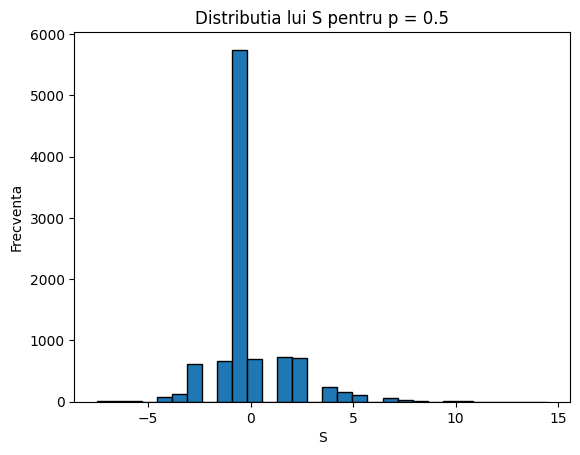

In [17]:
plt.hist(valori_S, bins=30, edgecolor='black')

plt.title('Distributia lui S pentru p = 0.5')
plt.xlabel('S')
plt.ylabel('Frecventa')

plt.show()

 ## d) p = 0.3 si p = 0.7
 ### Influenta probabilitatii p

Refacem simularea pentru p = 0.3 si p = 0.7, asa cum cere enuntul.
Compararea histogramelor permite observarea modului in care modificarea
probabilitatii de aparitie a stemei influenteaza distributia lui S.

p = 0.3
Media aproximativa a lui S = -0.2736


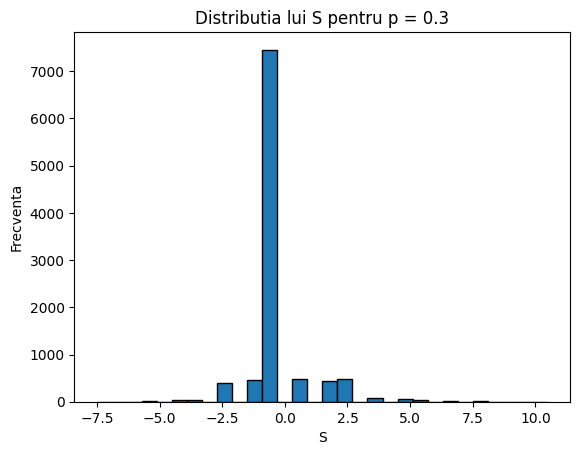

p = 0.7
Media aproximativa a lui S = 0.6809


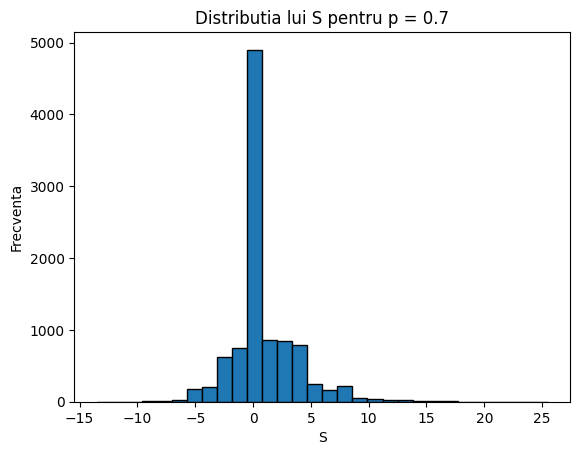

In [18]:
for p in [0.3, 0.7]:

    valori_S = []

    for i in range(10000):
        N, S = simulare_joc(p)
        valori_S.append(S)

    valori_S = np.array(valori_S)

    print("p =", p)
    print("Media aproximativa a lui S =", np.mean(valori_S))

    plt.hist(valori_S, bins=30, edgecolor='black')
    plt.title(f'Distributia lui S pentru p = {p}')
    plt.xlabel('S')
    plt.ylabel('Frecventa')
    plt.show()

###Exercitiul 3
#### Rezolvare

Sunt trei frizeri, cu vitezele medii de 3, 6 si 4 clienti pe ora.
Prin urmare, ratele distributiilor exponentiale sunt:

lambda_1 = 3
lambda_2 = 6
lambda_3 = 4

Probabilitatile ca un client sa fie preluat de cei trei frizeri sunt
3/13, 6/13 si 4/13.

Generam 10000 de valori pentru timpul X de servire. Mai intai alegem
frizerul conform probabilitatilor din enunt, apoi generam timpul de servire
din distributia exponentiala corespunzatoare.

In [19]:
import numpy as np
import matplotlib.pyplot as plt

numar_clienti = 10000

lambdas = np.array([3, 6, 4])
probabilitati = np.array([3/13, 6/13, 4/13])

# alegem frizerul pentru fiecare client
frizeri = np.random.choice(
    [0, 1, 2],
    size=numar_clienti,
    p=probabilitati
)

X = np.zeros(numar_clienti)

# generam timpul de servire
for i in range(numar_clienti):

    frizer = frizeri[i]

    X[i] = np.random.exponential(
        scale=1 / lambdas[frizer]
    )

#### Estimarea parametrilor

Folosim valorile generate pentru a estima media si deviatia standard a
timpului de servire X.

In [20]:
media = np.mean(X)
deviatia_standard = np.std(X)

print("Media aproximativa =", media)
print("Deviatia standard aproximativa =", deviatia_standard)

Media aproximativa = 0.2322400296418809
Deviatia standard aproximativa = 0.25037288935291596


### Densitatea aproximativa

Deoarece X este o variabila aleatoare continua, reprezentam o aproximare
a densitatii sale. Folosim `density=True` pentru ca histograma sa fie
normalizata si sa reprezinte densitatea aproximativa a distributiei lui X.

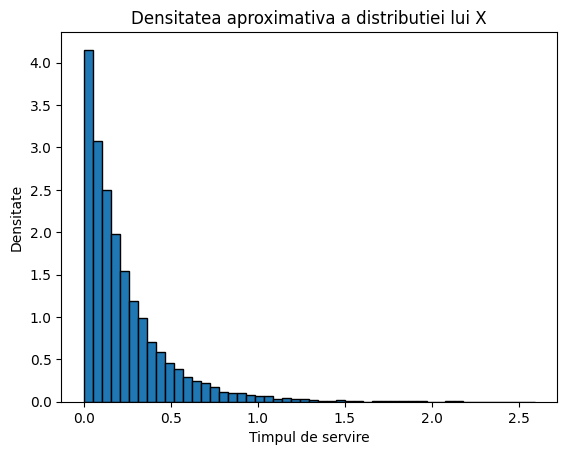

In [21]:
plt.hist(X, bins=50, density=True, edgecolor='black')

plt.title('Densitatea aproximativa a distributiei lui X')
plt.xlabel('Timpul de servire')
plt.ylabel('Densitate')

plt.show()